# Configuration

In [1]:
%run _dev_setup.py

🔁 Autoreload is ON (IPython detected).
✅ Using winners_curse from: /Users/iamsikun/Desktop/research/winners-curse/src/winners_curse


In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
from scipy.stats import ttest_1samp, norm, wilcoxon
from scipy.integrate import quad 

In [4]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 14
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [5]:
from winners_curse.dgp import RCTs, DataGenerationProcess
import winners_curse.rct as rct
from winners_curse.variables import *
from winners_curse.utils import *

## Experiment

In [95]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': None,
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': 2500}

experiment_params = {'n_repeats': 10000}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
}

base_tau = 1.0
delta_tau_list = [0.001, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2]

In [96]:
delta_tau1_result_dict = {delta_tau: None for delta_tau in delta_tau_list}

for delta_tau in delta_tau_list:
    print(f'\nDelta tau= {delta_tau}')
    
    dgp_params['base_effects'] = [PointMass(base_tau), PointMass(base_tau + delta_tau)]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    delta_tau1_result_dict[delta_tau] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Delta tau= 0.001
Running 10000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 7424 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:    0.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s



Delta tau= 0.005
Running 10000 experiments...


[Parallel(n_jobs=-1)]: Done 7424 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:    0.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s



Delta tau= 0.01
Running 10000 experiments...


...

[Parallel(n_jobs=-1)]: Done 7657 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:    0.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s



Delta tau= 0.1
Running 10000 experiments...


[Parallel(n_jobs=-1)]: Done 7890 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:    0.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s



Delta tau= 0.2
Running 10000 experiments...


[Parallel(n_jobs=-1)]: Done 7890 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:    0.6s finished


In [97]:
true_best = 1

for delta_tau in delta_tau_list:
    print(f'Delta tau = {delta_tau}')

    # accuracy
    focal_decisions = delta_tau1_result_dict[delta_tau]['rank_and_select_nc_selection_arr'].flatten()
    ss_decisions = delta_tau1_result_dict[delta_tau]['rank_and_select_sample_splitting_selection_arr'].flatten()

    focal_acc = np.mean(focal_decisions == true_best)
    focal_acc_se = np.std(focal_decisions == true_best) / np.sqrt(experiment_params['n_repeats'])
    ss_acc = np.mean(ss_decisions == true_best)
    ss_acc_se = np.std(ss_decisions == true_best) / np.sqrt(experiment_params['n_repeats'])

    norm_ratio = np.sqrt(data_params['sample_size'] / 2) * (delta_tau / dgp_params['noise_vars'][0].std)
    focal_acc_true = norm.cdf(norm_ratio)
    ss_acc_true = norm.cdf(norm_ratio / np.sqrt(2))

    print(f'    Accuracy: Empirical = {focal_acc:.4%} ({focal_acc_se:.4%}), Theoretical = {focal_acc_true:.4%}')
    print(f'    Accuracy: Empirical = {ss_acc:.4%} ({ss_acc_se:.4%}), Theoretical = {ss_acc_true:.4%}')

Delta tau = 0.001
    Accuracy: Empirical = 51.8800% (0.4996%), Theoretical = 51.4102%
    Accuracy: Empirical = 50.6900% (0.5000%), Theoretical = 50.9973%
Delta tau = 0.005
    Accuracy: Empirical = 57.2300% (0.4947%), Theoretical = 57.0158%
    Accuracy: Empirical = 54.6700% (0.4978%), Theoretical = 54.9738%
Delta tau = 0.01
    Accuracy: Empirical = 64.0600% (0.4798%), Theoretical = 63.8163%
    Accuracy: Empirical = 59.5900% (0.4907%), Theoretical = 59.8706%
Delta tau = 0.02
    Accuracy: Empirical = 76.2000% (0.4259%), Theoretical = 76.0250%
    Accuracy: Empirical = 69.1100% (0.4620%), Theoretical = 69.1462%
Delta tau = 0.03
    Accuracy: Empirical = 85.5800% (0.3513%), Theoretical = 85.5578%
    Accuracy: Empirical = 77.6900% (0.4163%), Theoretical = 77.3373%
Delta tau = 0.04
    Accuracy: Empirical = 92.1100% (0.2696%), Theoretical = 92.1350%
    Accuracy: Empirical = 84.3000% (0.3638%), Theoretical = 84.1345%
Delta tau = 0.05
    Accuracy: Empirical = 95.8900% (0.1985%), Theor

In [98]:
true_best = 1

for delta_tau in delta_tau_list:
    print(f'Delta tau = {delta_tau}')
    norm_ratio = np.sqrt(data_params['sample_size'] / 2) * (delta_tau / dgp_params['noise_vars'][0].std)

    focal_val_mean = np.mean(delta_tau1_result_dict[delta_tau]['rank_and_select_nc_val_true_arr'].flatten())
    focal_val_se = np.std(delta_tau1_result_dict[delta_tau]['rank_and_select_nc_val_true_arr'].flatten()) / np.sqrt(experiment_params['n_repeats'])
    ss_val_mean = np.mean(delta_tau1_result_dict[delta_tau]['rank_and_select_sample_splitting_val_true_arr'].flatten())
    ss_val_se = np.std(delta_tau1_result_dict[delta_tau]['rank_and_select_sample_splitting_val_true_arr'].flatten()) / np.sqrt(experiment_params['n_repeats'])

    gap_arr = delta_tau1_result_dict[delta_tau]['rank_and_select_nc_val_true_arr'].flatten() - delta_tau1_result_dict[delta_tau]['rank_and_select_sample_splitting_val_true_arr'].flatten()
    gap_arr_se = np.std(gap_arr) / delta_tau / np.sqrt(experiment_params['n_repeats'])
    gap_arr_mean = np.mean(gap_arr) / delta_tau

    focal_val_true = 1 + delta_tau * norm.cdf(norm_ratio)
    ss_val_true = 1 + delta_tau * norm.cdf(norm_ratio / np.sqrt(2))
    gap_true = (focal_val_true - ss_val_true) / delta_tau

    print(f'    Whole Sample: Empirical = {focal_val_mean:.4f} ({focal_val_se:.4f}), Theoretical = {focal_val_true:.4f}')
    print(f'    Half Sample: Empirical = {ss_val_mean:.4f} ({ss_val_se:.4f}), Theoretical = {ss_val_true:.4f}')
    print(f'    Gap: Empirical = {gap_arr_mean:.4%} ({gap_arr_se:.4%}), Theoretical = {gap_true:.4%}')

Delta tau = 0.001
    Whole Sample: Empirical = 1.0005 (0.0000), Theoretical = 1.0005
    Half Sample: Empirical = 1.0005 (0.0000), Theoretical = 1.0005
    Gap: Empirical = 1.1900% (0.4982%), Theoretical = 0.4129%
Delta tau = 0.005
    Whole Sample: Empirical = 1.0029 (0.0000), Theoretical = 1.0029
    Half Sample: Empirical = 1.0027 (0.0000), Theoretical = 1.0027
    Gap: Empirical = 2.5600% (0.4949%), Theoretical = 2.0420%
Delta tau = 0.01
    Whole Sample: Empirical = 1.0064 (0.0000), Theoretical = 1.0064
    Half Sample: Empirical = 1.0060 (0.0000), Theoretical = 1.0060
    Gap: Empirical = 4.4700% (0.4855%), Theoretical = 3.9457%
Delta tau = 0.02
    Whole Sample: Empirical = 1.0152 (0.0001), Theoretical = 1.0152
    Half Sample: Empirical = 1.0138 (0.0001), Theoretical = 1.0138
    Gap: Empirical = 7.0900% (0.4592%), Theoretical = 6.8787%
Delta tau = 0.03
    Whole Sample: Empirical = 1.0257 (0.0001), Theoretical = 1.0257
    Half Sample: Empirical = 1.0233 (0.0001), Theoretical

## Visualization

In [6]:
sample_sizes: list = [500, 2500, 10000]
delta_tau_list: list = np.linspace(0.001, 0.1, 500)
noise_std = 1

sample_size_result_dict = {
    sample_size: {
        'gap_arr': np.zeros(len(delta_tau_list)), 
        'gap_argmax': None, 
        'gap_max': None
    } for sample_size in sample_sizes
}

for sample_size in tqdm(sample_sizes, desc='Sample Size', total=len(sample_sizes)):
    for delta_tau_idx, delta_tau in tqdm(enumerate(delta_tau_list), desc='Delta tau', total=len(delta_tau_list), leave=False):        
        norm_ratio = np.sqrt(sample_size / 2) * (delta_tau / noise_std)
        focal_val_true = 1 + delta_tau * norm.cdf(norm_ratio)
        ss_val_true = 1 + delta_tau * norm.cdf(norm_ratio / np.sqrt(2))

        sample_size_result_dict[sample_size]['gap_arr'][delta_tau_idx] = (focal_val_true - ss_val_true) / delta_tau
        sample_size_result_dict[sample_size]['gap_argmax'] = 2 * np.sqrt(np.log(2) / sample_size)
        sample_size_result_dict[sample_size]['gap_max'] = norm.cdf(np.sqrt(2 * np.log(2))) - norm.cdf(np.sqrt(np.log(2)))

Sample Size: 100%|██████████| 3/3 [00:00<00:00, 15.94it/s]


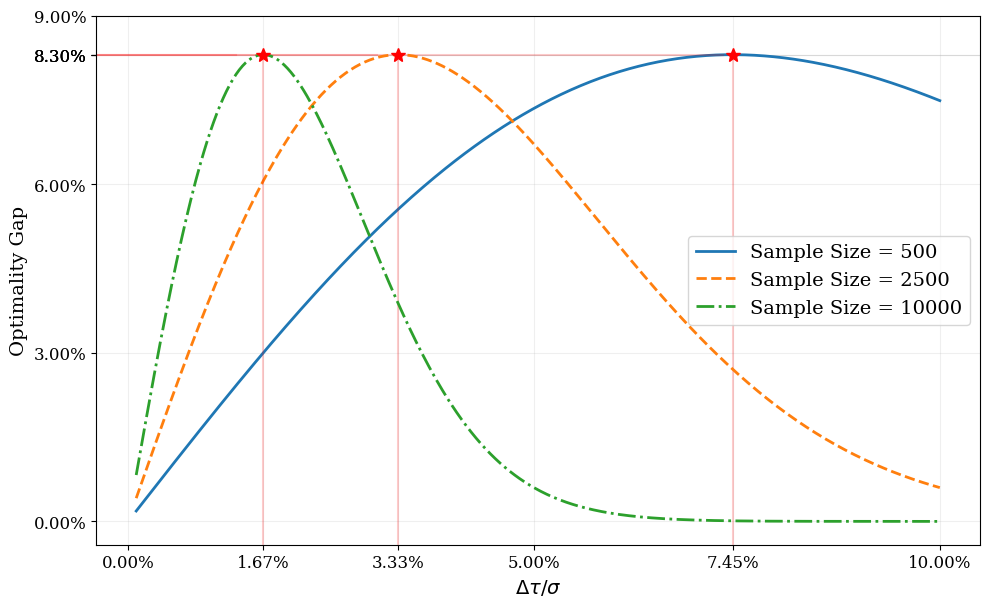

In [7]:
# visualize
fig, ax = plt.subplots(figsize=(10, 6.18))

line_styles = {'500': 'solid', '2500': 'dashed', '10000': 'dashdot'}

for idx, sample_size in enumerate(sample_sizes):
    ax.plot(
        np.array(delta_tau_list) / noise_std * 100, 
        sample_size_result_dict[sample_size]['gap_arr'] * 100, 
        label=f'Sample Size = {sample_size}', 
        color=f'C{idx}', 
        linestyle=line_styles[str(sample_size)], 
        linewidth=2
    )
    
    # plot the maximum gap as a star
    ax.plot(
        sample_size_result_dict[sample_size]['gap_argmax'] / noise_std * 100, 
        sample_size_result_dict[sample_size]['gap_max'] * 100, 
        marker='*', 
        markersize=10, 
        color=f'red'
    )
    x_max = sample_size_result_dict[sample_size]['gap_argmax'] / noise_std * 100
    y_max = sample_size_result_dict[sample_size]['gap_max'] * 100
    ax.axvline(
        x_max, 
        ymin=0, 
        ymax=y_max / 9, 
        color='red', 
        linestyle='-', 
        alpha=0.2
    )
    ax.axhline(
        y_max, 
        xmin=0, 
        xmax=x_max / np.max(ax.get_xlim()), 
        color='red', 
        linestyle='-', 
        alpha=0.2
    )

ax.grid(True, alpha=0.2)
x_ticks = sorted([0, 5, 10] + [d_['gap_argmax'] / noise_std * 100 for d_ in sample_size_result_dict.values()])
y_ticks = sorted([0, 3, 6, 9] + [d_['gap_max'] * 100 for d_ in sample_size_result_dict.values()])
ax.set_xticks(x_ticks, [f'{x:.2f}%' for x in x_ticks])
ax.set_yticks(y_ticks, [f'{y:.2f}%' for y in y_ticks])
ax.set_xlabel(r'$\Delta \tau / \sigma$', fontsize=axis_label_size)
ax.set_ylabel('Optimality Gap', fontsize=axis_label_size)
# ax.set_title(r'Decision Value Gap between Whole Sample and Half Sample Relative to $\Delta\tau$')
ax.legend(fontsize=legend_label_size)
ax.tick_params(labelsize=tick_label_size)
plt.tight_layout()
plt.savefig('../figures/sample_splitting_value_loss.pdf')
plt.show()
